In [3]:
import pandas as pd
import os
from datetime import datetime, date
import matplotlib.pyplot as plt

### Read Dataframes

In [4]:

BASE_PATH = os.path.abspath('../data/raw')

df_companies = pd.read_csv(os.path.join(BASE_PATH, 'companies.csv'))
df_economic_data = pd.read_csv(os.path.join(BASE_PATH, 'economic_data.csv'))
df_purchases = pd.read_csv(os.path.join(BASE_PATH, 'purchases.csv'))

### Data Inspection

In [5]:
df_companies.head()

,company_id,company_name,location,company_type,employees
0,1,Adams-Rice,Douglastown,public,"500-1,000"
1,2,Olson-Schneider,Vaughnbury,private,1-10
2,3,"Smith, Weber and Spence",Francisborough,non-profit,101-500
3,4,Johnston and Sons,New Gloriamouth,private,"500-1,000"
4,5,"Sullivan, Kirby and Smith",Port Robynhaven,non-profit,1-10


GDP = Gross Domestic Product (PIB)

CPI = U.S. Consumer Price Index (IPC)

Mortgage Rate = (Tasa de Interés Hipotecario)

In [6]:
df_economic_data.head(10)

,Date,unemployment_rate,gdp_value,cpi,mortgage_rate_30y
0,1/31/2020,3.5,21481.367,257.971,3.51
1,4/30/2020,14.7,19477.444,256.389,3.23
2,7/31/2020,10.2,21138.574,259.101,2.99
3,10/31/2020,6.9,21477.597,260.388,2.81
4,1/31/2021,6.4,22038.226,261.582,2.73
5,4/30/2021,6.0,22740.959,267.054,2.98
6,7/31/2021,5.4,23202.344,273.003,2.80


In [7]:
print(df_purchases.head(5))
print('\n')
df_purchases.describe()

                  date  company_id   productcategory  quantity  revenue
0  2020-11-01 13:16:29           4            Gaming        58  2681.31
1  2021-06-16 21:03:11          10          Cookware        55  1032.50
2  2021-01-20 08:54:45           5        Home Decor        17  1226.12
3  2020-08-19 20:57:17           8         Computers        32  1743.84
4  2020-07-06 23:55:17           4  Home Improvement        76   851.12




,company_id,quantity,revenue
count,100000.000000,100000.000000,100000.000000
mean,5.501570,49.501700,1500.239419
std,2.866008,19.799915,499.024313
min,1.000000,1.000000,100.000000
25%,3.000000,36.000000,1162.720000
50%,5.000000,49.000000,1498.355000
75%,8.000000,63.000000,1836.887500
max,10.000000,139.000000,3512.590000


### Join data

In [8]:
# Adapt Date to a timestamp

df_economic_data_tmp = df_economic_data.copy()

df_economic_data_tmp['date'] = df_economic_data_tmp['Date'].apply(
    lambda x: datetime(
        year = int(x.split('/')[-1]),
        month = int(x.split('/')[0]),
        day = int(x.split('/')[1])
        )
)

df_economic_data_tmp = df_economic_data_tmp.drop(
    'Date',
    axis=1
)


df_economic_data_tmp.head()

,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,date
0,3.5,21481.367,257.971,3.51,2020-01-31
1,14.7,19477.444,256.389,3.23,2020-04-30
2,10.2,21138.574,259.101,2.99,2020-07-31
3,6.9,21477.597,260.388,2.81,2020-10-31
4,6.4,22038.226,261.582,2.73,2021-01-31


In [ ]:
# Adapt Date to a timestamp

df_purchases_tmp = df_purchases.copy()

df_purchases_tmp['date'] = df_purchases_tmp['date'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d %H:%M:%S')
)


df_purchases_tmp.head()

,date,company_id,productcategory,quantity,revenue
0,2020-11-01 13:16:29,4,Gaming,58,2681.31
1,2021-06-16 21:03:11,10,Cookware,55,1032.50
2,2021-01-20 08:54:45,5,Home Decor,17,1226.12
3,2020-08-19 20:57:17,8,Computers,32,1743.84
4,2020-07-06 23:55:17,4,Home Improvement,76,851.12


In [22]:
# A practice commonly done when dealing with time-series data is to set timestamp to a specific granularity
# and fill all values to that granularity

df_purchases_tmp['date'] = df_purchases_tmp['date'].apply(
    lambda x:
        date(
            year=x.year,
            month=x.month,
            day = x.day
        )
)

df_purchases_tmp.sort_values(by='date', ascending=True).head()

,date,company_id,productcategory,quantity,revenue
54718,2020-01-31,3,Gaming,35,1811.67
42431,2020-01-31,3,Home & Kitchen,34,1978.03
85115,2020-01-31,9,Pet Supplies,66,1324.84
99301,2020-01-31,4,Smart Home,9,2023.87
55948,2020-01-31,5,Toys & Games,13,477.54


In [55]:
# Group by date, company_id and productcategory and sum quantity and revenue
df_purchases_tmp = df_purchases_tmp.groupby(
    ['date', 'company_id', 'productcategory'],
    as_index=False
).agg(
    {
        'quantity':'sum',
        'revenue':'sum'
    }
)

df_purchases_tmp = df_purchases_tmp.dropna()

# df_purchases_tmp = df_purchases_tmp.apply(
#     lambda x: datetime.strftime(str(x), '%y-%m-%d')
# )

# datetime.strftime(str(df_purchases_tmp.loc[0, 'date']), '%y-%m-%d')
df_purchases_tmp['quantity']

0        144
1         50
2         18
3        113
4         45
        ... 
70848     25
70849    183
70850    145
70851    170
70852    107
Name: quantity, Length: 70853, dtype: int64

In [46]:
df_purchases_tmp.dtypes

date                object
company_id           int64
productcategory     object
quantity             int64
revenue            float64
dtype: object

In [40]:
## Fill missing dates with zero values on quantity and revenue

min_date = min(df_purchases_tmp['date'])
max_date = max(df_purchases_tmp['date'])

dti = pd.DataFrame(
        {'date' : pd.date_range(
            start = min_date,
            end = max_date,
            freq = 'D'
        )}
)

df_company_ids = df_purchases_tmp[['company_id']].drop_duplicates()
df_productcategories = df_purchases_tmp[['productcategory']].drop_duplicates()

dti = pd.merge(
    dti,
    df_company_ids,
    how='cross'
)

dti = pd.merge(
    dti,
    df_productcategories,
    how='cross'
)

dti.head(20)


,date,company_id,productcategory
0,2020-01-31,1,Appliances
1,2020-01-31,1,Audio
2,2020-01-31,1,Books & E-readers
3,2020-01-31,1,Cameras
4,2020-01-31,1,Clothing
5,2020-01-31,1,Electronics
6,2020-01-31,1,Fitness & Health
7,2020-01-31,1,Footwear
8,2020-01-31,1,Home & Kitchen
9,2020-01-31,1,Pet Supplies


In [45]:
df_purchases_tmp.dtypes

date                object
company_id           int64
productcategory     object
quantity             int64
revenue            float64
dtype: object

In [36]:
df_purchases_tmp_ = pd.merge(
    df_purchases_tmp,
    dti,
    on=['date', 'company_id', 'productcategory'],
    how='outer'
)

df_purchases_tmp_.head()

ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [10]:


df_tmp = pd.merge(
    df_purchases_tmp,
    df_economic_data_tmp,
    on='date',
    how='outer'
)


df_tmp.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y
0,2020-01-31 00:00:00,NaN,NaN,NaN,NaN,3.5,21481.367,257.971,3.51
1,2020-01-31 00:00:10,7.0,Toys & Games,45.0,1707.94,NaN,NaN,NaN,NaN
2,2020-01-31 00:36:08,7.0,Smart Home,71.0,1510.22,NaN,NaN,NaN,NaN
3,2020-01-31 00:52:35,3.0,Gaming,58.0,1006.68,NaN,NaN,NaN,NaN
4,2020-01-31 00:57:11,3.0,Wearable Tech,46.0,1840.69,NaN,NaN,NaN,NaN


In [11]:
# Fill forward Economic null values

df_tmp_filled = df_tmp.copy()

df_tmp_filled = df_tmp_filled.sort_values(by='date', ascending=True)

df_tmp_filled['unemployment_rate'] = df_tmp_filled['unemployment_rate'].ffill()
df_tmp_filled['gdp_value'] = df_tmp_filled['gdp_value'].ffill()
df_tmp_filled['cpi'] = df_tmp_filled['cpi'].ffill()
df_tmp_filled['mortgage_rate_30y'] = df_tmp_filled['mortgage_rate_30y'].ffill()


df_tmp_filled.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y
0,2020-01-31 00:00:00,NaN,NaN,NaN,NaN,3.5,21481.367,257.971,3.51
1,2020-01-31 00:00:10,7.0,Toys & Games,45.0,1707.94,3.5,21481.367,257.971,3.51
2,2020-01-31 00:36:08,7.0,Smart Home,71.0,1510.22,3.5,21481.367,257.971,3.51
3,2020-01-31 00:52:35,3.0,Gaming,58.0,1006.68,3.5,21481.367,257.971,3.51
4,2020-01-31 00:57:11,3.0,Wearable Tech,46.0,1840.69,3.5,21481.367,257.971,3.51


In [12]:
# Join with Companies

df_tmp_filled_ = df_tmp_filled.copy()
df_companies_tmp = df_companies.copy()

df_companies_tmp = df_companies_tmp.rename(
    columns={'id': 'company_id'}
)


df_silver = pd.merge(
    df_tmp_filled_,
    df_companies_tmp,
    on = 'company_id',
    how='inner'
)
df_silver.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,company_name,location,company_type,employees
0,2020-01-31 00:00:10,7.0,Toys & Games,45.0,1707.94,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
1,2020-01-31 00:36:08,7.0,Smart Home,71.0,1510.22,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
2,2020-01-31 00:52:35,3.0,Gaming,58.0,1006.68,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
3,2020-01-31 00:57:11,3.0,Wearable Tech,46.0,1840.69,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
4,2020-01-31 00:58:07,8.0,Fitness & Health,45.0,2130.24,3.5,21481.367,257.971,3.51,"Jackson, Cabrera and Morales",Barnettfort,private,51-100


### Check if we have filled values correctly

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

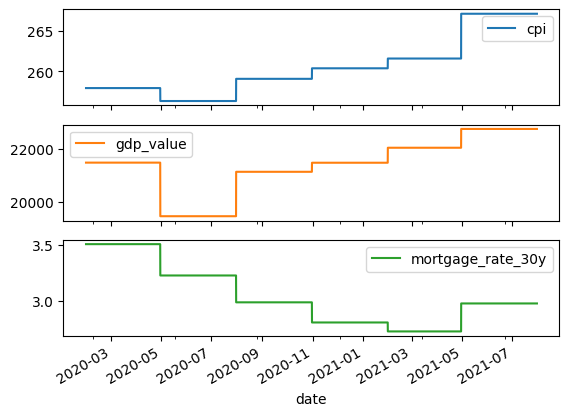

In [13]:
df_plot = df_silver[['date', 'cpi', 'gdp_value', 'mortgage_rate_30y']]
df_plot = df_plot.set_index('date')
df_plot.plot.line(subplots=True)

### Set datetime daily-granularity

In [17]:
mydate = date(year=2020, month=1, day=5)
mydate.month

1

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,company_name,location,company_type,employees
0,2020-01-31,7.0,Toys & Games,45.0,1707.94,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
1,2020-01-31,7.0,Smart Home,71.0,1510.22,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
2,2020-01-31,3.0,Gaming,58.0,1006.68,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
3,2020-01-31,3.0,Wearable Tech,46.0,1840.69,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
4,2020-01-31,8.0,Fitness & Health,45.0,2130.24,3.5,21481.367,257.971,3.51,"Jackson, Cabrera and Morales",Barnettfort,private,51-100


### Save Data in Silver Layer

In [8]:
df_silver.to_csv(os.path.abspath('../data/silver/joined_purchases.csv'), index=False)